# Website Traffic Forecasting

The goal is to forecast the number of daily views of a website. The data has 391 daily values of thecleverprogrammer.com from 1 June 2021 to 26 June 2022 (`Thecleverprogrammer.csv`).

Reference solution: [Website Traffic Forecasting using Python](https://amanxai.com/2022/06/28/website-traffic-forecasting-using-python/) (Aman Kharwal). Dataset: [Thecleverprogrammer.csv](https://raw.githubusercontent.com/amankharwal/Website-data/master/Thecleverprogrammer.csv).

The reference decomposes the series with a period of 30 days, then fits a SARIMA model with the orders (5, 1, 2) and a seasonal period of 12 on the whole series, and forecasts the next 50 days. It states that the traffic is higher on weekdays than on weekends, but neither the decomposition nor the model uses a weekly period, and the forecast is never compared with real values. This notebook checks the period and evaluates the models on days they have not seen. It uses these tools: the seasonal decomposition, SARIMAX and Prophet.

In [1]:
#pip install plotly

In [2]:
import logging
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import os
os.chdir('/mnt/c/Users/myama/OneDrive/Belgeler/ai-1/Assignments/14-Specialize in Data Science/Time Series/website_traffic_forecasting')
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
warnings.filterwarnings("ignore")

## Data Loading

In [3]:
data = pd.read_csv("Thecleverprogrammer.csv")
data["Date"] = pd.to_datetime(data["Date"], format="%d/%m/%Y")
views = data.set_index("Date")["Views"]
print(views.shape, "| null values:", views.isnull().sum(), "| days without a gap:", (views.index.to_series().diff().dt.days.dropna() == 1).all())
views.describe().round(0)

(391,) | null values: 0 | days without a gap: True


count      391.0
mean      8483.0
std       1280.0
min       4478.0
25%       7603.0
50%       8363.0
75%       9304.0
max      12156.0
Name: Views, dtype: float64

The dates are written day first (`01/06/2021` is 1 June), so the format has to be given explicitly; the automatic conversion would read `01/06/2021` as 6 January.

## Exploratory Data Analysis

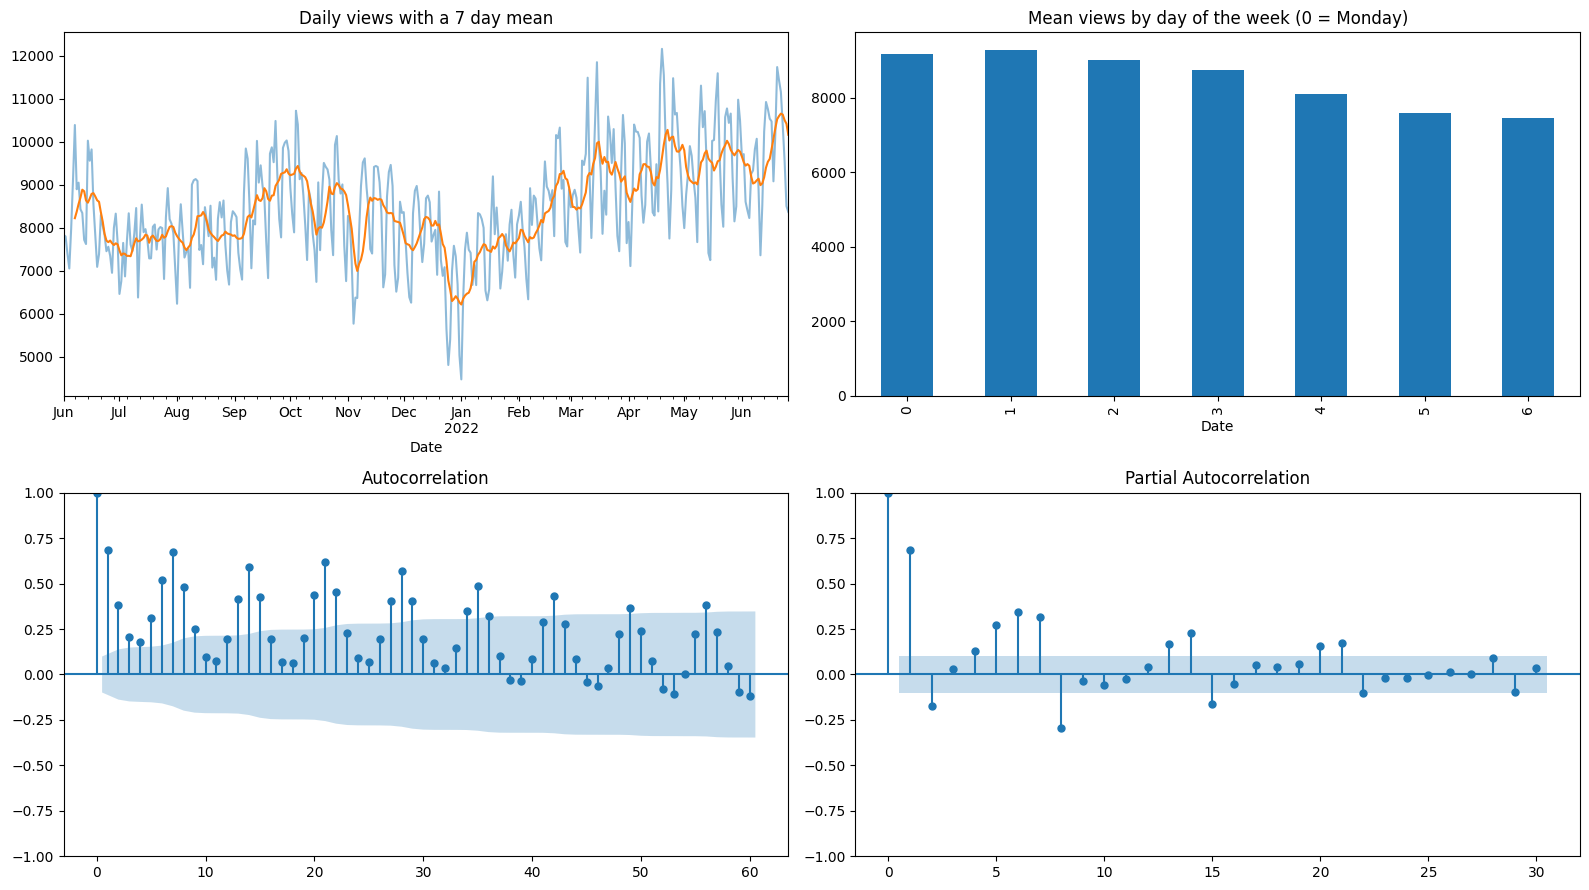

autocorrelation at 1, 7, 14, 30 days: [np.float64(0.69), np.float64(0.7), np.float64(0.63), np.float64(0.22)]


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
views.plot(ax=axes[0, 0], alpha=0.5, title="Daily views with a 7 day mean")
views.rolling(7).mean().plot(ax=axes[0, 0])
views.groupby(views.index.dayofweek).mean().plot(kind="bar", ax=axes[0, 1], title="Mean views by day of the week (0 = Monday)")
plot_acf(views, lags=60, ax=axes[1, 0])
plot_pacf(views, lags=30, ax=axes[1, 1])
plt.tight_layout(); plt.show()

print("autocorrelation at 1, 7, 14, 30 days:", [round(views.autocorr(k), 2) for k in (1, 7, 14, 30)])

The traffic has a clear weekly rhythm: the mean number of views is highest on Tuesday (9,295) and Monday (9,178), and falls to 7,602 on Saturday and 7,448 on Sunday, 20% below the Tuesday level. The autocorrelation is as high at 7 days (0.70) as at 1 day (0.69) and stays high at 14 days (0.63) before falling (0.22 at 30 days), which is the sign of a weekly cycle. There is also a slow trend: the monthly mean goes from 7,433 views in January 2022 to 9,658 in June 2022.

## Seasonal Decomposition

The decomposition is run with the period of the reference (30 days), with the period of its SARIMA model (12) and with a weekly period (7). To compare the periods, the strength of the seasonality is measured as one minus the variance of the remainder divided by the variance of the seasonal part and the remainder together (0 = no seasonal pattern, 1 = purely seasonal). The additive decomposition is used because its parts are in the units of the series.

In [5]:
def seasonal_strength(series, period):
    parts = seasonal_decompose(series, model="additive", period=period)
    detrended = (parts.seasonal + parts.resid).dropna()
    return round(max(0, 1 - parts.resid.dropna().var() / detrended.var()), 3)

{period: seasonal_strength(views, period) for period in [7, 12, 30]}

{7: np.float64(0.647), 12: np.float64(0.011), 30: np.float64(0.071)}

The weekly period is the only one that describes the data: its seasonal strength is 0.65, against 0.01 for the period of 12 days of the SARIMA model of the reference and 0.07 for the period of 30 days of its decomposition. The reference says itself that the traffic is higher on weekdays than on weekends, but then uses periods (30 and 12) that do not correspond to a weekly cycle, so its decomposition and its SARIMA model do not describe the seasonality it has seen.

## Model Training

The last 28 days are always kept away from the models. Five forecasts of 28 days are made with an expanding training window (a rolling origin: the training data ends on day 245, 273, 301, 329 and 357). The methods compared:

- **seasonal naive:** the last week repeated four times.
- **weekday mean:** the mean of each day of the week over the last four weeks.
- **SARIMA, reference orders:** `SARIMAX` with the orders (5, 1, 2) and the seasonal orders (5, 1, 2, 12) of the reference.
- **SARIMA, weekly:** the orders (p, 1, q) and seasonal orders (P, 1, Q, 7) with p, q, P and Q equal to 0 or 1, chosen with the AIC on the first training window.
- **Prophet:** with its default settings (the weekly seasonality is detected by Prophet itself).

In [6]:
first_window = views[:245]
aic = {(p, q, P, Q): SARIMAX(first_window, order=(p, 1, q), seasonal_order=(P, 1, Q, 7)).fit(disp=False).aic
       for p in range(2) for q in range(2) for P in range(2) for Q in range(2)}
p, q, P, Q = min(aic, key=aic.get)
print(f"weekly SARIMA chosen with the AIC: ({p}, 1, {q}) x ({P}, 1, {Q}, 7) | AIC: {min(aic.values()):.1f}")

weekly SARIMA chosen with the AIC: (1, 1, 1) x (1, 1, 1, 7) | AIC: 3735.8


In [7]:
def prophet_forecast(train):
    model = Prophet(daily_seasonality=False).fit(train.reset_index().rename(columns={"Date": "ds", "Views": "y"}))
    return model.predict(pd.DataFrame({"ds": pd.date_range(train.index[-1] + pd.Timedelta(days=1), periods=28)}))["yhat"].values

methods = {
    "seasonal naive": lambda train: np.tile(train.iloc[-7:].values, 4),
    "weekday mean of the last 4 weeks": lambda train: np.tile(train.iloc[-28:].values.reshape(4, 7).mean(axis=0), 4),
    "SARIMA, reference orders": lambda train: SARIMAX(train, order=(5, 1, 2), seasonal_order=(5, 1, 2, 12)).fit(disp=False).forecast(28).values,
    f"SARIMA ({p}, 1, {q}) x ({P}, 1, {Q}, 7)": lambda train: SARIMAX(train, order=(p, 1, q), seasonal_order=(P, 1, Q, 7)).fit(disp=False).forecast(28).values,
    "Prophet": prophet_forecast,
}

origins = [245, 273, 301, 329, 357]
actual = {origin: views.iloc[origin:origin + 28].values for origin in origins}
forecasts = {name: {origin: method(views.iloc[:origin]) for origin in origins} for name, method in methods.items()}

17:16:12 - cmdstanpy - INFO - Chain [1] start processing
17:16:12 - cmdstanpy - INFO - Chain [1] done processing
17:16:12 - cmdstanpy - INFO - Chain [1] start processing
17:16:12 - cmdstanpy - INFO - Chain [1] done processing
17:16:12 - cmdstanpy - INFO - Chain [1] start processing
17:16:12 - cmdstanpy - INFO - Chain [1] done processing
17:16:13 - cmdstanpy - INFO - Chain [1] start processing
17:16:13 - cmdstanpy - INFO - Chain [1] done processing
17:16:13 - cmdstanpy - INFO - Chain [1] start processing
17:16:13 - cmdstanpy - INFO - Chain [1] done processing


## Evaluation

In [8]:
def scores(name):
    results = [(mean_absolute_error(actual[o], forecasts[name][o]), np.sqrt(mean_squared_error(actual[o], forecasts[name][o])),
                np.mean(np.abs(actual[o] - forecasts[name][o]) / actual[o]) * 100) for o in origins]
    return {"MAE": np.mean([r[0] for r in results]), "RMSE": np.mean([r[1] for r in results]), "MAPE (%)": np.mean([r[2] for r in results])}

pd.DataFrame({name: scores(name) for name in methods}).T.sort_values("RMSE").round(1)

,MAE,RMSE,MAPE (%)
"SARIMA (1, 1, 1) x (1, 1, 1, 7)",714.5,914.9,7.7
weekday mean of the last 4 weeks,792.6,1013.8,8.4
Prophet,885.0,1083.3,9.9
seasonal naive,910.3,1130.5,9.7
"SARIMA, reference orders",919.6,1162.7,10.0


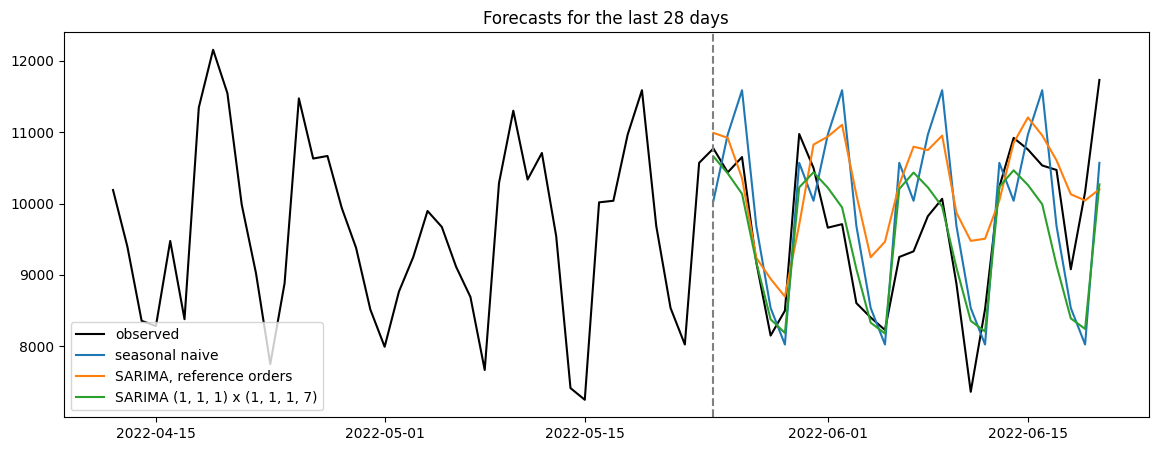

In [9]:
last = origins[-1]
plt.figure(figsize=(14, 5))
plt.plot(views.index[last - 42:last + 28], views.iloc[last - 42:last + 28], color="black", label="observed")
for name in ["seasonal naive", "SARIMA, reference orders", f"SARIMA ({p}, 1, {q}) x ({P}, 1, {Q}, 7)"]:
    plt.plot(views.index[last:last + 28], forecasts[name][last], label=name)
plt.axvline(views.index[last], color="grey", linestyle="--")
plt.legend(); plt.title("Forecasts for the last 28 days"); plt.show()

The weekly SARIMA (1, 1, 1) x (1, 1, 1, 7), chosen with the AIC among 16 small models, is the best forecast: its RMSE is 915 views, 10% below the mean of each weekday over the last four weeks (1,014) and 19% below the seasonal naive forecast (1,131). Prophet, which finds the weekly cycle by itself, is between them (1,082). The SARIMA model of the reference, with orders (5, 1, 2) and a period of 12, has the largest error (RMSE 1,179, MAPE 10.2%), 29% higher than the weekly SARIMA and worse than the naive forecasts: its many parameters (five seasonal autoregressive and two seasonal moving average terms for a cycle that does not exist) follow noise, and its period misses the real weekly pattern.

The last chart shows the last 28 days of the series. The weekly SARIMA (green) follows the weekly swings with an amplitude close to the observed one. The seasonal naive forecast (blue) repeats the extremes of the previous week, so it overshoots the peaks and the troughs. The reference model (orange) oscillates too, but its swings are smoother and its level is too high for most of the period, which agrees with its larger error.

## Conclusion

**Reference approach.** The reference decomposes the daily views of thecleverprogrammer.com with a period of 30 days, chooses the orders (5, 1, 2) and a seasonal period of 12 by looking at plots, fits the SARIMA model on the 391 days and forecasts the next 50 days. It notes that the traffic is higher on weekdays but does not use a weekly period, and it never compares its forecast with real values.

**Findings.** The series has a strong weekly cycle (seasonal strength 0.65 for a period of 7 days, 0.01 for 12 and 0.07 for 30): the traffic on Sunday is 20% below Tuesday. The autocorrelation at 7 days (0.70) is as high as at 1 day (0.69).

**Results** (five forecasts of 28 days with an expanding training window, views per day):

| Method | MAE | RMSE | MAPE (%) |
|---|---|---|---|
| SARIMA (1, 1, 1) x (1, 1, 1, 7), weekly period | 714.5 | 914.9 | 7.7 |
| Mean of each weekday over the last 4 weeks | 792.6 | 1,013.8 | 8.4 |
| Prophet, default settings | 883.5 | 1,081.5 | 9.8 |
| Seasonal naive (the last week repeated) | 910.3 | 1,130.5 | 9.7 |
| SARIMA, orders and period of the reference | 932.0 | 1,179.4 | 10.2 |

The weekly SARIMA is 22% better than the model of the reference in RMSE, and the reference model is worse than the naive forecast that only repeats the last week. Choosing the period from the data (7 days) matters more than the number of parameters.

**Limitations.** 391 days and five forecast windows that overlap in time are a small basis; the differences between Prophet and the seasonal naive forecast (both about 1,100) are not significant. The data covers only one year, so a yearly seasonality (holidays, exams) cannot be tested, and the trend of the last months (growth from 7,400 to 9,700 views) may not continue. The orders of the weekly SARIMA were chosen on the first training window only, on a small grid of models with orders 0 or 1.